### imports

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import hypertools as hyp
from os.path import join as opj
from scipy.spatial.distance import pdist

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# try to show progress bars for long-running cells
# to properly show progress bars, you'll need to install tqdm,
# as well as widgetsnbextension and ipywidgets to render the element
try:
    from tqdm import tqdm_notebook as tqdm
    show_pbars = True
except ModuleNotFoundError:
    print('To enable progress bars, install tqdm module (`pip install tqdm`)')
    show_pbars = False

### set paths

In [3]:
data_dir = '../../data/'
ep_data_dir = opj(data_dir, 'models', 'episodes')
rec_data_dir = opj(data_dir, 'models', 'recalls')
ep_events_dir = opj(ep_data_dir, 'events')
ep_embs_dir = opj(ep_data_dir, 'embeddings')
rec_events_dir = opj(rec_data_dir, 'events')
rec_embs_dir = opj(rec_data_dir, 'embeddings')
pickle_dir = opj(data_dir, 'pickles')

### load data

In [4]:
# episode events
episode_events = {ep : np.load(opj(ep_events_dir, f'{ep}_events.npy')) 
                  for ep in ['atlep1', 'atlep2', 'arrdev']}

# individual recall events
recall_events = {rectype: {} for rectype in ['atlep1', 'delayed', 'atlep2', 'arrdev']}
# average recall events
avg_recall_events = dict.fromkeys(recall_events.keys())
# episode-recall event mappings
event_mappings = dict.fromkeys(recall_events.keys())

for root, dirs, files in os.walk(rec_events_dir):
    event_models = [f for f in files if f.endswith('npy')]
    rectype = os.path.split(root)[-1]
    if rectype == 'prediction':
        continue
    for f_name in event_models:
        m = np.load(opj(root, f_name), allow_pickle=True)
        if f_name.startswith('debug'):
            recall_events[rectype][f_name.split('_')[0]] = m
        elif f_name.startswith('avg_events'):
            avg_recall_events[rectype] = m
        else:
            event_mappings[rectype] = m
        
# session 1/session 2 psiturk ID mapppings
id_maps = pd.read_pickle(opj(pickle_dir, 'id_maps.p'))

In [5]:
# with open(opj(pickle_dir, 'embeddings_opt.p'), 'rb') as f:
#     results = pickle.load(f)

### define functions

In [6]:
def r2z(r):
    """
    Function that calculates the Fisher z-transformation
 
    Parameters
    ----------
    r : int or ndarray
        Correlation value
 
    Returns
    ----------
    result : int or ndarray
        Fishers z transformed correlation value
 
    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))

In [7]:
def spatial_similarity(embedding, original_pdist, emb_metric):
    """
    computes correlation between pairwise 
    euclidean distance in embedding space and 
    correlation distance in originnal space
    """
    emb_pdist = pdist(embedding, emb_metric)
    if emb_metric == 'correlation':
        emb_pdist = r2z(emb_pdist)
    return 1 - pdist((original_pdist, emb_pdist), 'correlation')[0]

In [8]:
#source: https://stackoverflow.com/questions/563198/how-do-you-detect-where-two-line-segments-intersect
def segments_intersect2d(a1, b1, a2, b2):
    s1 = b1 - a1
    s2 = b2 - a2
    
    s = (-s1[1] * (a1[0] - a2[0]) + s1[0] * (a1[1] - a2[1])) / (-s2[0] * s1[1] + s1[0] * s2[1])
    t = ( s2[0] * (a1[1] - a2[1]) - s2[1] * (a1[0] - a2[0])) / (-s2[0] * s1[1] + s1[0] * s2[1])
    
    if (s >= 0) and (s <= 1) and (t >= 0) and (t <= 1):
        return True
    else:
        return False

In [9]:
def n_intersections(x):
    intersections = 0
    for i in np.arange(x.shape[0] - 1):
        a1 = x[i, :]
        b1 = x[i+1, :]
        for j in np.arange(i+2, x.shape[0] - 1):
            a2 = x[j, :]
            b2 = x[j+1, :]
            
            if segments_intersect2d(a1, b1, a2, b2):           
                intersections += 1
    return intersections

# filter video event with no successful recalls from avg recall events

In [10]:
for rectype in avg_recall_events.keys():
    no_rec_mask = np.all(np.equal(avg_recall_events[rectype], 0), axis=1)
    avg_recall_events[rectype] = avg_recall_events[rectype][~no_rec_mask]

# optimize embedding

In [11]:
np.random.seed(0)
seeds = np.arange(2500)

In [21]:
results_euc = dict.fromkeys(recall_events.keys())
results_corr = dict.fromkeys(recall_events.keys())
results_intersect = dict.fromkeys(recall_events.keys())



for i, (rectype, evs) in enumerate(recall_events.items()):
    print(f'optimizing {rectype}...')
    res_e = []
    res_c = []
    res_i = []

    if rectype == 'delayed':
        ep_events = episode_events['atlep1']
    else:
        ep_events = episode_events[rectype]
        
    ep_events_pdist = 1 - r2z(1 - pdist(ep_events, 'correlation'))
    
    data = [ep_events, avg_recall_events[rectype]]
    for ev in evs.values():
        data.append(ev)
        
    if show_pbars:
        seeds_iter = tqdm(seeds, leave=False)
    else:
        seeds_iter = seeds
        
    for seed in seeds_iter:
        np.random.seed(None)
        np.random.seed(seed)
        emb = hyp.reduce(data, reduce={'model': 'UMAP', 'params' : {'random_state': seed}}, ndims=2)
        res_e.append(spatial_similarity(emb[0], ep_events_pdist, 'euclidean'))
        res_c.append(spatial_similarity(emb[0], ep_events_pdist, 'correlation'))
        res_i.append(n_intersections(emb[0]))
        break
    break
    results_euc[rectype] = res_e
    results_corr[rectype] = res_c
    results_intersect[rectype] = res_i

optimizing atlep1...


# optimize by preservation of spatial relationships

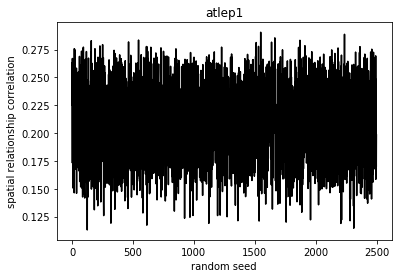

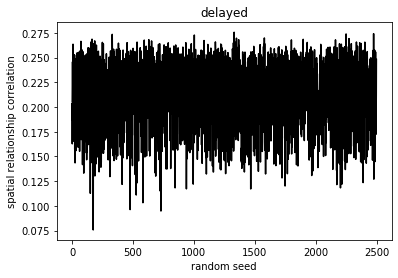

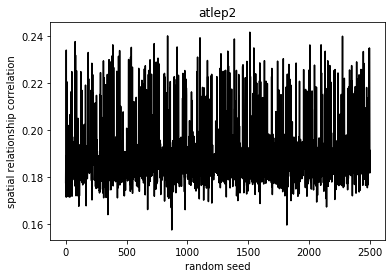

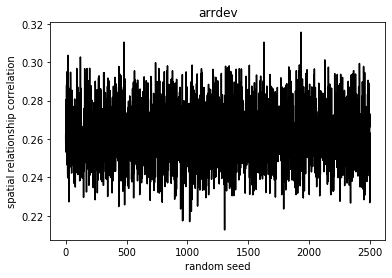

In [45]:
for rectype, res in results_euc.items():
    plt.plot(seeds, res, color='k')
    plt.title(rectype)
    plt.xlabel('random seed')
    plt.ylabel('spatial relationship correlation')
    plt.show()

atlep1 optimal seed: 1549, r=0.29054468864493366
0.29054468864493366


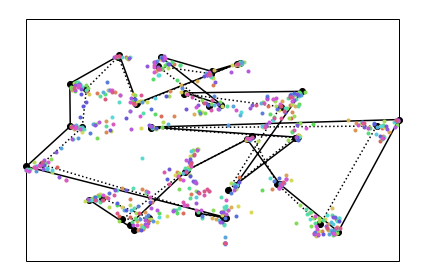

delayed optimal seed: 1331, r=0.27565447768014884
0.27565447768014884


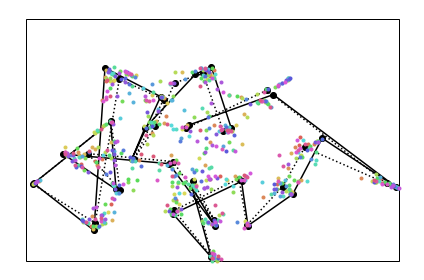

atlep2 optimal seed: 1512, r=0.24180972097643283
0.24180972097643283


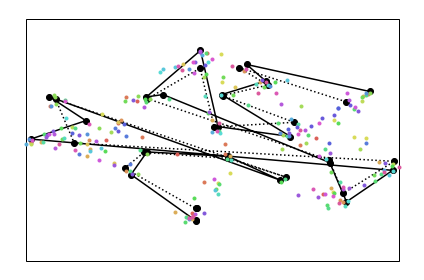

arrdev optimal seed: 1932, r=0.3156272486105842
0.3156272486105842


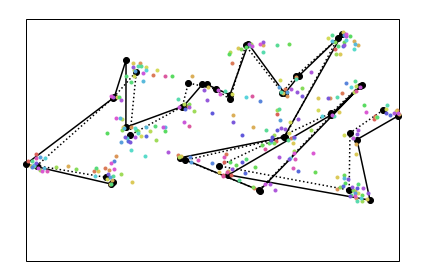

In [49]:
opt_embeddings_euc = dict.fromkeys(results_euc.keys())

for rectype, res in results_euc.items():
    opt_seed = np.argmax(res)
    print(f'{rectype} optimal seed: {opt_seed}, r={res[opt_seed]}')
    ep_events = episode_events['atlep1'] if rectype == 'delayed' else episode_events[rectype]    
    ep_events_pdist = 1 - r2z(1 - pdist(ep_events, 'correlation'))
    
    data = [ep_events, avg_recall_events[rectype]]
    # make sure embedding is matched to proper subject after reducing
    track_turkids = []
    for turkid, evs in recall_events[rectype].items():
        track_turkids.append(turkid)
        data.append(evs)

    emb_dict = {}
    np.random.seed(None)
    np.random.seed(opt_seed)
    emb = hyp.reduce(data, reduce={'model': 'UMAP', 'params' : {'random_state': opt_seed}}, ndims=2)
    print(spatial_similarity(emb[0], ep_events_pdist, 'euclidean'))
    
    emb_dict['episode'] = emb[0]
    emb_dict['avg_recall'] = emb[1]
    indvs = {}
    for turkid, sub_emb in zip(track_turkids, emb[2:]):
        indvs[turkid] = sub_emb 
    emb_dict['recalls'] = indvs
    opt_embeddings_euc[rectype] = emb_dict
    
    # plot optimal embedding:
    styles = ['ko-', 'ko:']
    styles.extend(['.']*(len(emb)-2))
    hyp.plot(emb, styles)

# optimize by minimum number of episode intersections

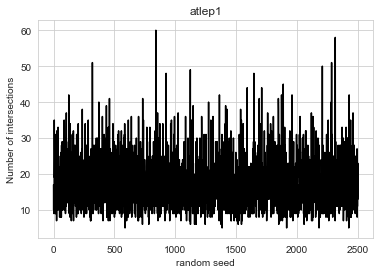

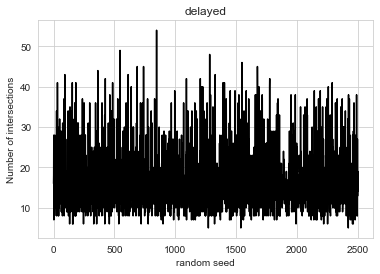

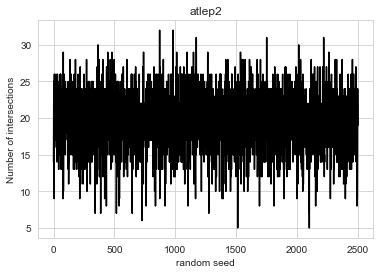

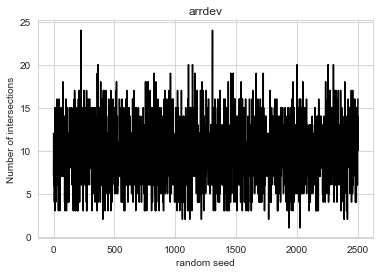

In [51]:
for rectype, res in results_intersect.items():
    plt.plot(seeds, res, color='k')
    plt.title(rectype)
    plt.xlabel('random seed')
    plt.ylabel('Number of intersections')
    plt.show()

In [55]:
np.argwhere(results_intersect['atlep1'] == np.min(results_intersect['atlep1']))

array([[ 587],
       [1384],
       [1914],
       [2180],
       [2424]])

atlep1 minimum intersections: 5
optimal seeds:
	[587]
	intersections: 16


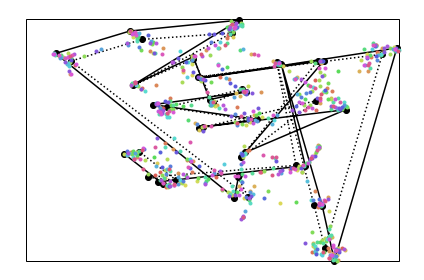

	[1384]
	intersections: 16


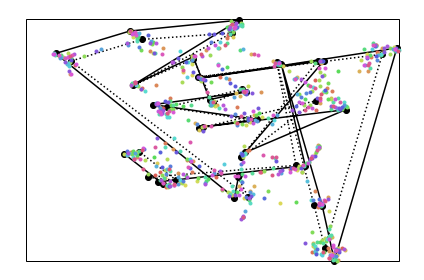

	[1914]
	intersections: 16


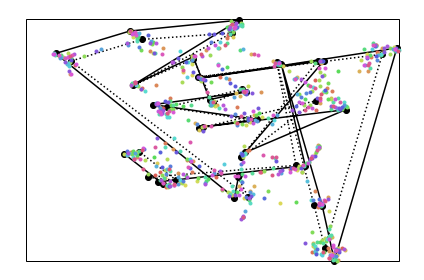

	[2180]
	intersections: 16


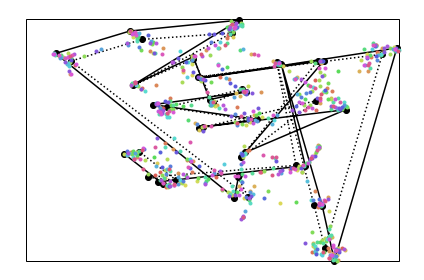

	[2424]
	intersections: 16


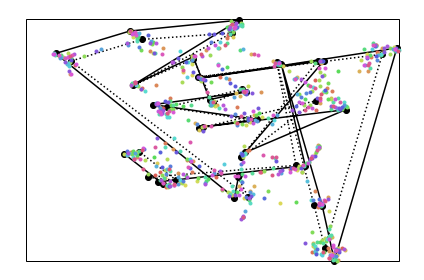

delayed minimum intersections: 5
optimal seeds:
	[587]
	intersections: 18


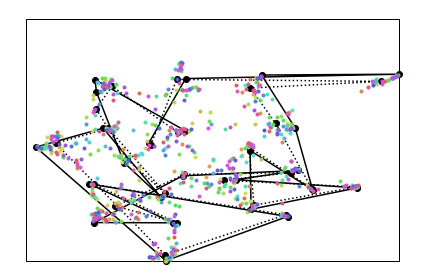

	[1384]
	intersections: 18


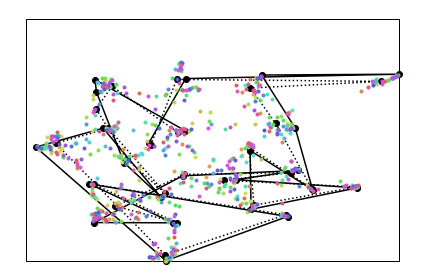

	[1914]
	intersections: 18


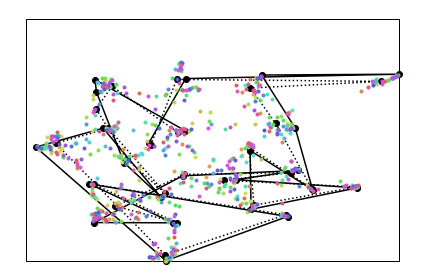

	[2180]
	intersections: 18


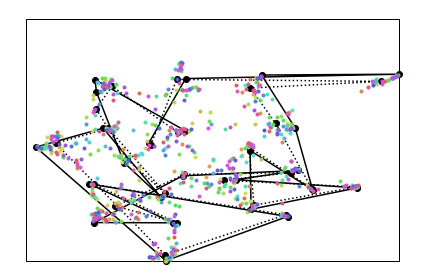

	[2424]
	intersections: 18


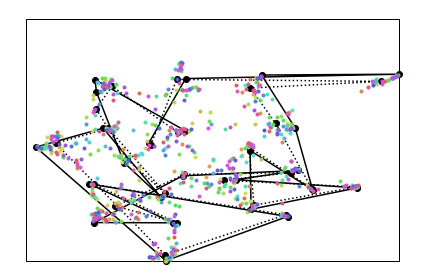

atlep2 minimum intersections: 5
optimal seeds:
	[587]
	intersections: 15


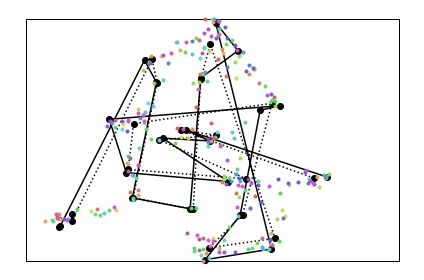

	[1384]
	intersections: 15


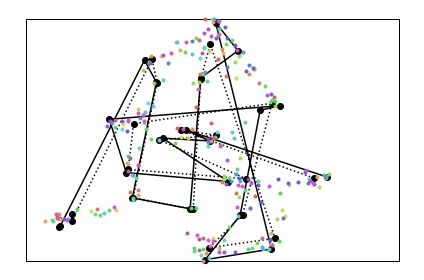

	[1914]
	intersections: 15


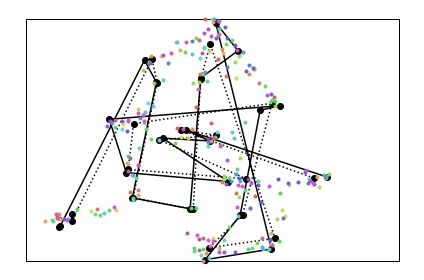

	[2180]
	intersections: 15


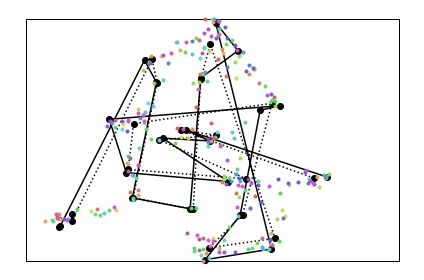

	[2424]
	intersections: 15


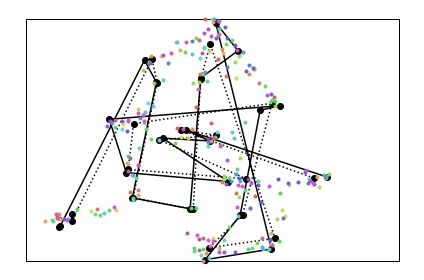

arrdev minimum intersections: 1
optimal seeds:


In [56]:
opt_embeddings_intersect = dict.fromkeys(results_intersect.keys())

for rectype, res in results_intersect.items():
    min_intersections = np.min(results_intersect[rectype])
    print(f'{rectype} minimum intersections: {min_intersections}')    
    ep_events = episode_events['atlep1'] if rectype == 'delayed' else episode_events[rectype]
    data = [ep_events, avg_recall_events[rectype]]
    # make sure embedding is matched to proper subject after reducing
    track_turkids = []
    for turkid, evs in recall_events[rectype].items():
        track_turkids.append(turkid)
        data.append(evs)

    optimal_seeds = np.argwhere(results_intersect['atlep1'] == min_intersections)
    print('optimal seeds:')
    
    for s in optimal_seeds:
        print(f'\t{s}')
#     emb_dict = {}
        np.random.seed(None)
        np.random.seed(opt_seed)
        emb = hyp.reduce(data, reduce={'model': 'UMAP', 'params' : {'random_state': opt_seed}}, ndims=2)
        print(f'\tintersections: {n_intersections(emb[0])}')
    
#     emb_dict['episode'] = emb[0]
#     emb_dict['avg_recall'] = emb[1]
#     indvs = {}
#     for turkid, sub_emb in zip(track_turkids, emb[2:]):
#         indvs[turkid] = sub_emb 
#     emb_dict['recalls'] = indvs
#     opt_embeddings_euc[rectype] = emb_dict
    
        # plot optimal embeddings:
        styles = ['ko-', 'ko:']
        styles.extend(['.']*(len(emb)-2))
        hyp.plot(emb, styles)

In [75]:
with open('/Users/paxtonfitzpatrick/Desktop/optimized_seeds_cluster/optimal_seeds.p', 'rb') as f:
    optimal_seeds = pickle.load(f)

In [76]:
optimal_seeds

{'atlep1': {'dispersion': array([ 22,  23,  25,  27,  42,  50,  66,  83,  91,  96,  99, 109, 135,
         142, 144, 154, 155, 156, 158, 184]),
  'intersections': array([79]),
  'similarity_euc': array([  4,  14,  59,  67,  87,  88,  97, 105, 107, 114, 121, 123, 125,
         131, 146, 148, 161, 171, 175, 193]),
  'similarity_corr': array([ 23,  25,  26,  34,  45,  52,  58,  82,  85,  91, 103, 104, 111,
         122, 149, 150, 195])},
 'delayed': {'dispersion': array([ 22,  23,  25,  27,  42,  50,  66,  83,  91,  96,  99, 109, 135,
         142, 144, 154, 155, 156, 158, 184]),
  'intersections': array([79]),
  'similarity_euc': array([  4,  14,  59,  67,  87,  88,  97, 105, 107, 114, 121, 123, 125,
         131, 146, 148, 161, 171, 175, 193]),
  'similarity_corr': array([ 23,  25,  26,  34,  45,  52,  58,  82,  85,  91, 103, 104, 111,
         122, 149, 150, 195])},
 'atlep2': {'dispersion': array([ 23,  27,  39,  42,  47,  49,  52,  66,  73,  91, 106, 109, 132,
         152, 154, 160,

In [82]:
x = np.random.rand(1000000)

In [86]:
import sys

In [90]:
'1000'.isdigit()

True

In [93]:
opj('asdf', 'jklp') + 'test'

'asdf/jklptest'

In [99]:
a = 'a'
b = 'b'
c = 'c'
test = [a, b, c]
for i, t in enumerate(test):
    test[i] = t + 'testtest'

In [100]:
test

['atesttest', 'btesttest', 'ctesttest']

In [101]:
a,b,c

('a', 'b', 'c')